# Dataset & model setup

In [ ]:
# Import modules
import os
import sys
import torch
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import random
import torch.nn.functional as F
import copy
import matplotlib.pyplot as plt
import numpy as np
import time
import io
import json

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Load CIFAR-10 Dataset
d = './data'
if not os.path.exists(d):
    os.mkdir(d)

train_transforms = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])
test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

train_set = datasets.CIFAR10(root=d, train=True, transform=train_transforms, download=True)
test_set = datasets.CIFAR10(root=d, train=False, transform=test_transforms, download=True)

batch_size = 32
global_train_loader = torch.utils.data.DataLoader(
                 dataset=train_set,
                 batch_size=batch_size,
                 shuffle=True)
global_test_loader = torch.utils.data.DataLoader(
                dataset=test_set,
                batch_size=batch_size,
                shuffle=False)

100%|██████████| 170M/170M [00:03<00:00, 43.0MB/s]


In [ ]:
# Use ResNet-18 model with
# models.resnet18(weights=None, num_classes=10)

# Client Creation

Voici le nombre de labels dans la classe 0 : 5000 et les indices sont [   29    30    35 ... 49941 49992 49994]
Voici le nombre de labels dans la classe 1 : 5000 et les indices sont [    4     5    32 ... 49993 49998 49999]
Voici le nombre de labels dans la classe 2 : 5000 et les indices sont [    6    13    18 ... 49987 49991 49995]
Voici le nombre de labels dans la classe 3 : 5000 et les indices sont [    9    17    21 ... 49979 49982 49983]
Voici le nombre de labels dans la classe 4 : 5000 et les indices sont [    3    10    20 ... 49981 49984 49990]
Voici le nombre de labels dans la classe 5 : 5000 et les indices sont [   27    40    51 ... 49964 49980 49988]
Voici le nombre de labels dans la classe 6 : 5000 et les indices sont [    0    19    22 ... 49962 49966 49996]
Voici le nombre de labels dans la classe 7 : 5000 et les indices sont [    7    11    12 ... 49965 49978 49986]
Voici le nombre de labels dans la classe 8 : 5000 et les indices sont [    8    62    69 ... 49968 49976

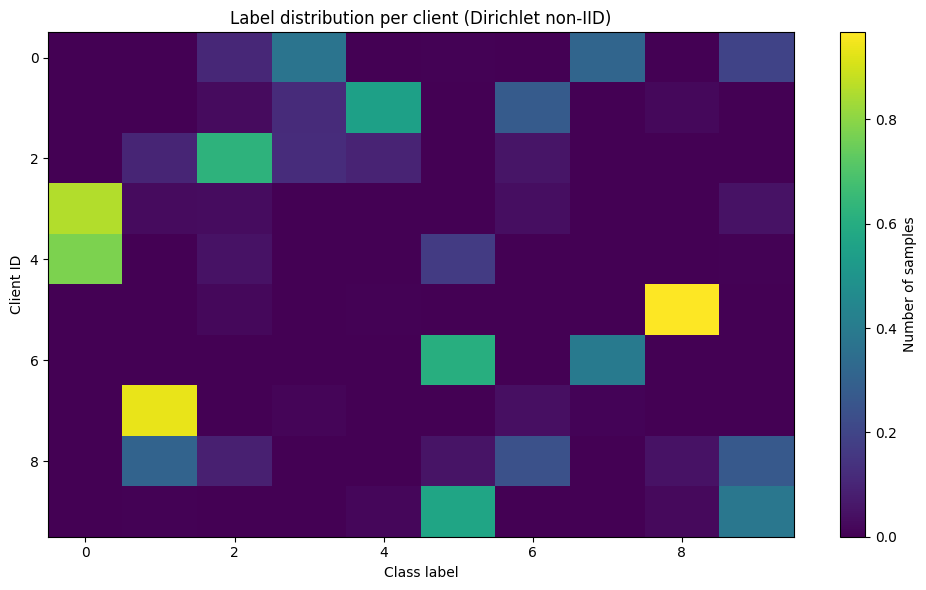

[np.int64(9348), np.int64(8299), np.int64(4056), np.int64(1750), np.int64(4471), np.int64(4484), np.int64(5121), np.int64(1593), np.int64(9828), np.int64(1050)]


In [ ]:
from collections import defaultdict
from torch.utils.data import Subset, DataLoader
from collections import Counter
import matplotlib.pyplot as plt


def Dirichlet(labels, alpha, num_clients) :
    n_classes = len(np.unique(labels))
    client_indices = defaultdict(list)

    np.random.seed(42)
    torch.manual_seed(42)

    for c in range(n_classes):
        labels = np.array(train_set.targets)
        idx = np.where(labels == c)[0]
        print("Voici le nombre de labels dans la classe", c, ":", len(idx), "et les indices sont", idx )
        np.random.shuffle(idx)
        proportions = np.random.dirichlet([alpha] * num_clients)
        proportions = (np.cumsum(proportions) * len(idx)).astype(int)[:-1]
        splits = np.split(idx, proportions)


        for client_id, split in enumerate(splits):
            client_indices[client_id].extend(split)

    for cid in range(num_clients):
        if len(client_indices[cid]) == 0:
            random_idx = np.random.randint(0, len(labels))
            client_indices[cid].append(random_idx)
            print(f"Warning: Client {cid} était vide, un échantillon a été ajouté.")


    return client_indices



def count_labels_per_client(train_set, client_indices, num_classes=10):
    counts = np.zeros((len(client_indices), num_classes), dtype=int)

    for cid, indices in client_indices.items():
        labels = np.array(train_set.targets)[indices]
        counter = Counter(labels)
        for cls, cnt in counter.items():
            counts[cid, cls] = cnt

    return counts


def plot_label_distribution(counts):
    plt.figure(figsize=(10, 6))
    plt.imshow(counts, aspect="auto")
    plt.colorbar(label="Number of samples")
    plt.xlabel("Class label")
    plt.ylabel("Client ID")
    plt.title("Label distribution per client (Dirichlet non-IID)")
    plt.tight_layout()
    plt.show()



def build_client_datasets(
    num_clients=10,
    alpha=0.5,
    batch_size=32,
):

    labels = train_set.targets
    client_indices = Dirichlet(labels, alpha, num_clients)

    counts = count_labels_per_client(train_set, client_indices, num_classes=10)
    print(counts)
    counts_norm = counts / counts.sum(axis=1, keepdims=True)
    plot_label_distribution(counts_norm)

    i = 0
    clients = []

    for cid, indices in client_indices.items():

        model = models.resnet18(weights=None, num_classes=10).to(device)

        number_sample = 0
        for j in range (len(counts[i])) :
          number_sample += counts[i][j]


        loader = torch.utils.data.DataLoader(
                  dataset= Subset(train_set, indices) ,
                  batch_size=batch_size,
                  shuffle=True,
                  drop_last=True) #supprime le batch s'il fait moinsde 32 images j'en avais besoin pour éviter des erreurs de batch de size 1

        client = {"client_id": i,
            "local_dataset": loader,
            "local_model" : model,
            "optimizer": optim.SGD(model.parameters(), lr=0.01, momentum=0.9),
            "number_sample" : number_sample}

        clients.append(client)
        i += 1


    return clients


clients = build_client_datasets(    num_clients=10,
    alpha=0.1,
    batch_size=32)

print([x["number_sample"] for x in clients])

# Federated Learning Training

In [ ]:
def client_load_model(client, model):
    client["local_model"].load_state_dict(model.state_dict())

def client_local_training(client, global_model, mu = 0.01):
    criterion = nn.CrossEntropyLoss()
    optimizer = client["optimizer"]
    dataset = client["local_dataset"]
    model = client["local_model"].to(device)
    model.train()

    for batch_idx, (x, target) in enumerate(dataset):
        x, target = x.to(device), target.to(device)
        out = model(x)
        proximal_term = 0.0
        for w, w_t in zip(model.parameters(), global_model.parameters()):
            proximal_term = (w - w_t).norm(2)**2
        loss = criterion(out, target) + proximal_term
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

def server_aggregate_models(clients):
    models = [x["local_model"].state_dict() for x in clients]
    number_sample = [x["number_sample"] for x in clients]
    total_sample = sum(number_sample)
    averaged_model = copy.deepcopy(models[0])
    with torch.no_grad():
        for k in averaged_model.keys():
          i = 0
          somme = 0
          for m in models :
            somme += m[k] * number_sample[i]
            i += 1
          averaged_model[k]  = somme / total_sample
    return averaged_model

def evaluate(model, dataset):
    model.to(device)
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss, total, correct = 0, 0, 0

    with torch.no_grad():
        for x, target in dataset:
            x, target = x.to(device), target.to(device)
            out = model(x)
            loss = criterion(out, target)
            _, pred_label = torch.max(out, 1)
            total_loss += loss.item()
            total += x.size(0)
            correct += (pred_label == target).sum().item()

    avg_loss = total_loss / len(dataset)
    acc = correct / total
    print(f"loss: {avg_loss:.4f}, acc: {acc:.4f}")
    return avg_loss, acc

def get_model_size(model):
    buffer = io.BytesIO()
    torch.save(model.state_dict(), buffer)
    size_MB = buffer.getbuffer().nbytes / 1e6
    return size_MB

def federated_learning_loop(save_dir):
    # Set seed
    torch.manual_seed(42)
    global_model = models.resnet18(weights=None, num_classes=10).to(device)

    client_participation_fraction = 0.2
    rounds = 750
    eval_interval = 10  # Measure costly metrics every X rounds
    save_interval = 50  # Save model every Y rounds
    os.makedirs(save_dir, exist_ok=True)

    metrics = {
        "round": [],
        "loss": [],
        "accuracy": [],
        "round_time": [],
        "model_size": []
    }
    best_acc = 0.0
    best_loss = np.inf

    for r in range(rounds):
        client_participating = []
        print(f"\nRound {r+1}")

        # Start the timer
        start_time = time.time()

        # Broadcast global model to clients
        for c in clients:
            client_load_model(c, global_model)

        # Selected clients perform local training
        for c in clients:
            if random.random() <= client_participation_fraction:
                client_local_training(c, global_model)
                client_participating.append(c)

        # Aggregate models from participating clients
        print(len(client_participating))
        if not client_participating :
          print("Saut de round")
          continue
        aggregated_model = server_aggregate_models(client_participating)

        # Update global model
        global_model.load_state_dict(aggregated_model)

        # Stop the timer before computing the metrics
        round_time = time.time() - start_time

        # Evaluation
        loss, acc = evaluate(global_model, global_test_loader)

        if (r + 1) % eval_interval == 0 or r == 0 or r == rounds - 1:
            model_size = get_model_size(global_model)
        else:
            model_size = metrics["model_size"][-1]

        # Save metrics for plotting
        metrics["round"].append(r+1)
        metrics["round_time"].append(round_time)
        metrics["loss"].append(loss)
        metrics["accuracy"].append(acc)
        metrics["model_size"].append(model_size)

        # Save model periodically
        if (r + 1) % save_interval == 0:
            torch.save(global_model.state_dict(), f"{save_dir}/model_round_{r+1}.pth")
            print(f"Saved checkpoint: model_round_{r+1}.pth")

        # Save best model so far
        if acc > best_acc:
            best_acc = acc
            torch.save(global_model.state_dict(), f"{save_dir}/best_acc.pth")
            print(f"New best acc model saved (acc={acc:.4f})")
        if loss < best_loss:
            best_loss = loss
            torch.save(global_model.state_dict(), f"{save_dir}/best_loss.pth")
            print(f"New best loss model saved (loss={loss:.4f})")

    # Save final model
    torch.save(global_model.state_dict(), f"{save_dir}/final_model.pth")
    print("Final model saved")

    return metrics

In [ ]:
def plot_metrics(metrics, filename):
    rounds = np.array(metrics["round"])
    loss = np.array(metrics["loss"])
    acc = np.array(metrics["accuracy"])
    round_time = np.array(metrics["round_time"])
    model_size = np.array(metrics["model_size"])

    plt.style.use('seaborn-v0_8-paper')

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.ravel()

    # Loss
    axes[0].plot(rounds, loss, color='tab:blue', linewidth=2)
    axes[0].set_title("Global Model Loss", fontsize=15)
    axes[0].set_xlabel("Round", fontsize=13)
    axes[0].set_ylabel("Loss", fontsize=13)
    axes[0].grid(True)

    # Accuracy
    axes[1].plot(rounds, acc, color='tab:orange', linewidth=2)
    axes[1].set_title("Global Model Accuracy", fontsize=15)
    axes[1].set_xlabel("Round", fontsize=13)
    axes[1].set_ylabel("Accuracy", fontsize=13)
    axes[1].grid(True)

    # Round time
    axes[2].plot(rounds, round_time, color='tab:green', linewidth=2)
    axes[2].set_title("Round Duration", fontsize=15)
    axes[2].set_xlabel("Round", fontsize=13)
    axes[2].set_ylabel("Time (s)", fontsize=13)
    axes[2].grid(True)

    # Model size
    axes[3].plot(rounds, model_size, color='tab:red', linewidth=2)
    axes[3].set_title("Model Size", fontsize=15)
    axes[3].set_xlabel("Round", fontsize=13)
    axes[3].set_ylabel("Size (MB)", fontsize=13)
    axes[3].grid(True)

    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Plot saved to {filename}")

In [ ]:
def summarize_metrics(metrics, filename):
    rounds = np.array(metrics["round"])
    losses = np.array(metrics["loss"])
    accs = np.array(metrics["accuracy"])
    round_times = np.array(metrics["round_time"])
    model_sizes = np.array(metrics["model_size"])

    mean_round_time = np.nanmean(round_times)
    std_round_time = np.nanstd(round_times)
    total_training_time = np.nansum(round_times)

    final_loss = losses[-1]
    final_acc = accs[-1]
    best_loss = np.nanmin(losses)
    best_loss_round = rounds[np.nanargmin(losses)]
    best_acc = np.nanmax(accs)
    best_acc_round = rounds[np.nanargmax(accs)]

    initial_model_size = model_sizes[0]
    final_model_size = model_sizes[-1]
    best_acc_model_size = model_sizes[np.nanargmax(accs)]
    best_loss_model_size = model_sizes[np.nanargmin(losses)]

    size_reduction = initial_model_size - final_model_size
    size_reduction_pct = (size_reduction / initial_model_size) * 100 if initial_model_size > 0 else 0
    size_reduction_best_acc = initial_model_size - best_acc_model_size
    size_reduction_pct_best_acc = (size_reduction_best_acc / initial_model_size) * 100 if initial_model_size > 0 else 0
    size_reduction_best_loss = initial_model_size - best_loss_model_size
    size_reduction_pct_best_loss = (size_reduction_best_loss / initial_model_size) * 100 if initial_model_size > 0 else 0

    acc_per_mb = best_acc / best_acc_model_size if best_acc_model_size > 0 else np.nan

    summary = {
        "final_loss": float(final_loss),
        "best_loss": float(best_loss),
        "final_accuracy": float(final_acc),
        "best_accuracy": float(best_acc),
        "best_loss_round": int(best_loss_round),
        "best_acc_round": int(best_acc_round),
        "mean_round_time": float(mean_round_time),
        "std_round_time": float(std_round_time),
        "total_training_time": float(total_training_time),
        "initial_model_size_MB": float(initial_model_size),
        "final_model_size_MB": float(final_model_size),
        "best_acc_model_size_MB": float(best_acc_model_size),
        "best_loss_model_size_MB": float(best_loss_model_size),
        "size_reduction_MB": float(size_reduction),
        "size_reduction_pct": float(size_reduction_pct),
        "size_reduction_best_acc_MB": float(size_reduction_best_acc),
        "size_reduction_pct_best_acc": float(size_reduction_pct_best_acc),
        "size_reduction_best_loss_MB": float(size_reduction_best_loss),
        "size_reduction_pct_best_loss": float(size_reduction_pct_best_loss),
        "accuracy_per_MB": float(acc_per_mb)
    }

    print("=== Training Summary ===")
    print(f"Final loss: {summary['final_loss']:.4f}")
    print(f"Best loss: {summary['best_loss']:.4f}")
    print(f"Final accuracy: {summary['final_accuracy']:.4f}")
    print(f"Best accuracy: {summary['best_accuracy']:.4f}")
    print(f"Best loss round: {summary['best_loss_round']}")
    print(f"Best accuracy round: {summary['best_acc_round']}")
    print()
    print(f"Mean round time: {summary['mean_round_time']:.3f} s")
    print(f"Std round time: {summary['std_round_time']:.3f} s")
    print(f"Total training time: {summary['total_training_time']:.3f} s")
    print()
    print(f"Initial model size: {summary['initial_model_size_MB']:.3f} MB")
    print(f"Final model size: {summary['final_model_size_MB']:.3f} MB")
    print(f"Model size at best accuracy: {summary['best_acc_model_size_MB']:.3f} MB")
    print(f"Model size at best loss: {summary['best_loss_model_size_MB']:.3f} MB")
    print()
    print(f"Size reduction (final): {summary['size_reduction_MB']:.3f} MB ({summary['size_reduction_pct']:.2f}%)")
    print(f"Size reduction (best accuracy): {summary['size_reduction_best_acc_MB']:.3f} MB ({summary['size_reduction_pct_best_acc']:.2f}%)")
    print(f"Size reduction (best loss): {summary['size_reduction_best_loss_MB']:.3f} MB ({summary['size_reduction_pct_best_loss']:.2f}%)")
    print()
    print(f"Accuracy per MB: {summary['accuracy_per_MB']:.4f}")

    with open(filename, "w") as f:
        json.dump(summary, f, indent=4)

    print(f"\nSummary saved to {filename}")
    return summary

In [ ]:
# Run loop
run_save_dir = "checkpoints"
metrics = federated_learning_loop(run_save_dir)


Round 1
1
loss: 7.2904, acc: 0.1000
New best acc model saved (acc=0.1000)
New best loss model saved (loss=7.2904)

Round 2
1
loss: 28.5335, acc: 0.1478
New best acc model saved (acc=0.1478)

Round 3
1
loss: 4.1680, acc: 0.1000
New best loss model saved (loss=4.1680)

Round 4
1
loss: 11.7305, acc: 0.1281

Round 5
1
loss: 6.2865, acc: 0.1000

Round 6
3
loss: 3.5278, acc: 0.1012
New best loss model saved (loss=3.5278)

Round 7
1
loss: 5.1158, acc: 0.1001

Round 8
1
loss: 5.5963, acc: 0.1000

Round 9
2
loss: 3.1584, acc: 0.1689
New best acc model saved (acc=0.1689)
New best loss model saved (loss=3.1584)

Round 10
2
loss: 3.2790, acc: 0.1599

Round 11
3
loss: 2.7849, acc: 0.1109
New best loss model saved (loss=2.7849)

Round 12
2
loss: 3.2790, acc: 0.1097

Round 13
1
loss: 4.4003, acc: 0.1148

Round 14
3
loss: 3.0171, acc: 0.1199

Round 15
3
loss: 2.6280, acc: 0.1692
New best acc model saved (acc=0.1692)
New best loss model saved (loss=2.6280)

Round 16
1
loss: 4.0415, acc: 0.1604

Round 

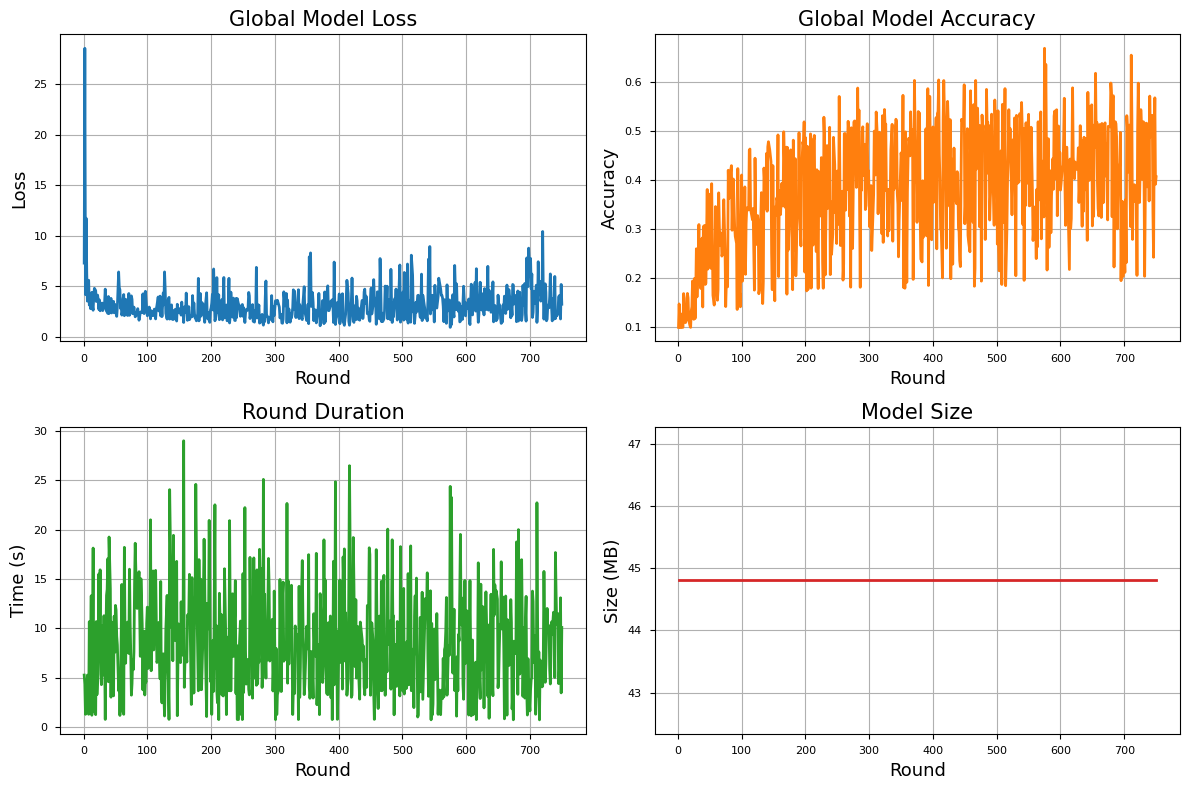

Plot saved to training_metrics.png


In [ ]:
# Plot metrics
metrics_filename = "training_metrics.png"
plot_metrics(metrics, metrics_filename)

In [ ]:
# Compute summary statistics
summary_filename = "summary.json"
summary = summarize_metrics(metrics, summary_filename)

=== Training Summary ===
Final loss: 3.2299
Best loss: 0.9368
Final accuracy: 0.4074
Best accuracy: 0.6695
Best loss round: 575
Best accuracy round: 575

Mean round time: 8.576 s
Std round time: 5.137 s
Total training time: 5685.903 s

Initial model size: 44.805 MB
Final model size: 44.805 MB
Model size at best accuracy: 44.805 MB
Model size at best loss: 44.805 MB

Size reduction (final): 0.000 MB (0.00%)
Size reduction (best accuracy): 0.000 MB (0.00%)
Size reduction (best loss): 0.000 MB (0.00%)

Accuracy per MB: 0.0149

Summary saved to summary.json


In [ ]:
!zip -r /content/{run_save_dir}.zip /content/{run_save_dir}/
from google.colab import files
files.download(f"/content/{run_save_dir}.zip")
files.download(f"/content/{metrics_filename}")
files.download(f"/content/{summary_filename}")

  adding: content/checkpoints/ (stored 0%)
  adding: content/checkpoints/model_round_600.pth (deflated 7%)
  adding: content/checkpoints/best_acc.pth (deflated 7%)
  adding: content/checkpoints/best_loss.pth (deflated 7%)
  adding: content/checkpoints/model_round_350.pth (deflated 7%)
  adding: content/checkpoints/model_round_200.pth (deflated 7%)
  adding: content/checkpoints/model_round_750.pth (deflated 7%)
  adding: content/checkpoints/model_round_650.pth (deflated 7%)
  adding: content/checkpoints/model_round_500.pth (deflated 7%)
  adding: content/checkpoints/model_round_250.pth (deflated 7%)
  adding: content/checkpoints/model_round_100.pth (deflated 7%)
  adding: content/checkpoints/final_model.pth (deflated 7%)
  adding: content/checkpoints/model_round_450.pth (deflated 7%)
  adding: content/checkpoints/model_round_400.pth (deflated 7%)
  adding: content/checkpoints/model_round_150.pth


zip error: Interrupted (aborting)


FileNotFoundError: Cannot find file: /content/checkpoints.zip